# Phase 3: X-Learner

**Goal:** Implement the X-Learner meta-learner and compare its uplift score distribution against the T-Learner from Phase 2.

**Why X-Learner:** The T-Learner trains two independent models and ignores the imbalance between groups. X-Learner addresses this by computing pseudo-treatment effects that borrow information across groups, making better use of the larger treatment group when estimating the control-side effect (and vice versa).

**Implementation:** `causalml` `BaseXClassifier` with `LGBMClassifier` (outcome learner) and `LGBMRegressor` (effect learner) as base models.

**Input:** `data/df_sample.parquet`

**Outputs:**
- `models/xlearner.pkl`
- `data/xlearner_scores.parquet` (uplift scores, true labels, treatment labels for Phase 4 evaluation)

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier, LGBMRegressor
from causalml.inference.meta import BaseXClassifier

%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", None)

## 2. Load Data

Load the same 50% stratified sample from Phase 1.

In [2]:
df = pd.read_parquet("../data/df_sample.parquet")
print("Shape:", df.shape)

Shape: (6989797, 16)


## 3. Train/Test Split

Use the exact same split as Phase 2 (`random_state=1`, stratified by visit x treatment) so the test set is identical and Phase 4 can compare T-Learner and X-Learner scores on the same users.

In [3]:
features = [f'f{i}' for i in range(12)]

X = df[features]
y = df['visit']
t = df['treatment']
stratify_col = y.astype('str') + '_' + t.astype('str')

X_train, X_test, y_train, y_test, t_train, t_test = train_test_split(
    X, y, t,
    test_size=0.2,
    random_state=1,
    stratify=stratify_col
)

print(f"Train: {len(X_train):,} rows | Test: {len(X_test):,} rows")
print(f"Treatment ratio in train: {t_train.mean():.3f}")
print(f"Treatment ratio in test:  {t_test.mean():.3f}")

Train: 5,591,837 rows | Test: 1,397,960 rows
Treatment ratio in train: 0.850
Treatment ratio in test:  0.850


## 4. Train X-Learner

X-Learner runs in four stages internally:

**Stage 1:** Train two base models, same as T-Learner. `µ_t` on treated users, `µ_c` on control users, both predicting `visit`.

**Stage 2:** Compute pseudo-treatment effects.   
For each treated user: `D_t = Y_t - µ_c(X_t)` (actual outcome minus what the control model would have predicted).   
For each control user: `D_c = µ_t(X_c) - Y_c` (what the treatment model predicts minus actual outcome).   
These pseudo-effects estimate the individual treatment effect for each user using the other group's model to impute the counterfactual.

**Stage 3:** Train two effect models.  
`τ_t` predicts `D_t` on treated users.  
`τ_c` predicts `D_c` on control users. 
These are now regression problems (predicting a continuous effect), not classification.

**Stage 4:** Combine using a propensity weight. `CATE(x) = g(x) · τ_c(x) + (1 - g(x)) · τ_t(x)` where `g(x) = P(T=1 | X=x)`. Since this is RCT data, `g(x)` is approximately constant at 0.85 across all users.

In [4]:
# Stage 1 and Stage 3 use different model types:
# outcome_learner = classifier (predicts binary visit label, same task as T-Learner)
# effect_learner  = regressor  (predicts continuous pseudo-effects computed in Stage 2)

params_cls = dict(
    n_estimators=200, learning_rate=0.05, num_leaves=31,
    min_child_samples=50,
    is_unbalance=True,      # handles class imbalance in visit label (4.7% positive rate)
    random_state=1, n_jobs=-1, verbose=-1
)
params_reg = dict(
    n_estimators=200, learning_rate=0.05, num_leaves=31,
    min_child_samples=50,
    # no is_unbalance: pseudo-effects are continuous values, not imbalanced binary labels
    random_state=1, n_jobs=-1, verbose=-1
)

# propensity = P(T=1), constant across users since this is RCT data (T ⊥ X)
# passing it explicitly avoids causalml running an unnecessary ElasticNet estimation
propensity = t_train.mean()  # ~0.85

# pass numpy arrays so fit and predict use the same dtype (avoids sklearn feature-name warnings)
learner_x = BaseXClassifier(
    outcome_learner=LGBMClassifier(**params_cls),
    effect_learner=LGBMRegressor(**params_reg),
)
learner_x.fit(X=X_train.values, treatment=t_train, y=y_train, p=np.full(len(X_train), propensity))

causalml runs all four stages internally with a single `fit` call. The `outcome_learner` (classifier) handles Stages 1 and 2, the `effect_learner` (regressor) handles Stage 3, and Stage 4 propensity weighting uses the constant `p` we passed in. The same hyperparameters as Phase 2 are used so any performance difference reflects the method, not the model setup.

## 5. Compute Uplift Scores

In [5]:
uplift_x = learner_x.predict(X=X_test.values, p=np.full(len(X_test), propensity))
uplift_x = pd.Series(uplift_x.flatten(), index=X_test.index, name="uplift")

print(f"Uplift scores computed for {len(uplift_x):,} users")
print(uplift_x.describe())

Uplift scores computed for 1,397,960 users
count    1.397960e+06
mean     1.166709e-01
std      1.485719e-01
min     -1.588499e-02
25%      1.074514e-02
50%      4.345043e-02
75%      1.769047e-01
max      7.290260e-01
Name: uplift, dtype: float64


`.flatten()` is needed because causalml returns a 2D array of shape `(n, 1)`. The mean (0.117) is much higher than the observed ATE (0.0103). This is expected since Stage 3 uses a regressor on continuous pseudo-effects, which are not constrained to be calibrated probabilities. The absolute score values are less meaningful than the ranking across users.

## 6. Compare with T-Learner

Load the T-Learner scores saved in Phase 2 and plot both distributions side by side. Formal evaluation (Qini curves, AUUC) is in Phase 4.

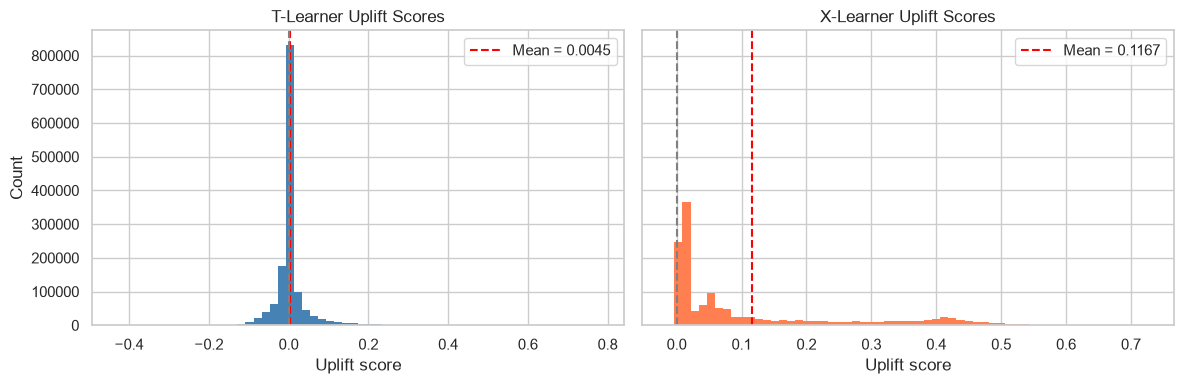

In [6]:
df_t = pd.read_parquet("../data/tlearner_scores.parquet")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

df_t["uplift"].hist(bins=60, ax=axes[0], color="steelblue", edgecolor="none")
axes[0].axvline(df_t["uplift"].mean(), color="red", linestyle="--", label=f"Mean = {df_t['uplift'].mean():.4f}")
axes[0].axvline(0, color="gray", linestyle="--")
axes[0].set_title("T-Learner Uplift Scores")
axes[0].set_xlabel("Uplift score")
axes[0].set_ylabel("Count")
axes[0].legend()

uplift_x.hist(bins=60, ax=axes[1], color="coral", edgecolor="none")
axes[1].axvline(uplift_x.mean(), color="red", linestyle="--", label=f"Mean = {uplift_x.mean():.4f}")
axes[1].axvline(0, color="gray", linestyle="--")
axes[1].set_title("X-Learner Uplift Scores")
axes[1].set_xlabel("Uplift score")
axes[1].legend()

plt.tight_layout()
plt.savefig("../images/uplift_distribution_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

| | T-Learner | X-Learner |
|---|---|---|
| Mean | 0.0045 | 0.1167 |
| Std | 0.0453 | 0.1486 |
| Median | 0.0005 | 0.0435 |
| Min | -0.4316 | -0.0159 |
| Max | 0.7809 | 0.7290 |

The two distributions look structurally different.

T-Learner produces a tight spike centered very close to zero, with almost all mass concentrated near the center and a modest right tail. X-Learner is much more spread out and shifted to the right. The bulk of scores fall between 0 and 0.2, with a long flat tail extending to 0.7 and almost no negative scores.

The X-Learner mean (0.117) is far above the observed ATE (0.0103), while T-Learner's mean (0.0045) is below it. The T-Learner underestimate reflects that with well-calibrated models, most users have near-zero per-user P(visit|T=1) - P(visit|T=0) differences. X-Learner's Stage 3 regressor predicts continuous pseudo-effects which are not constrained as calibrated probabilities, so its absolute scale differs from T-Learner. What matters is not the score values themselves but the ranking. Phase 4 evaluates this with the Qini curve.

Both models' max scores are similar (~0.73-0.78), reflecting the same underlying high-uplift users. Notably, the X-Learner distribution is robust to scale: its mean and spread barely changed from the 10% run (mean 0.117 → 0.117, std 0.149 → 0.149), while the T-Learner's mean shifted substantially (0.0155 → 0.0045). The X-Learner's pseudo-effect formulation is less sensitive to the 85/15 class imbalance than the T-Learner's direct probability subtraction.

## 7. Save Scores

In [7]:
os.makedirs("../data", exist_ok=True)
os.makedirs("../models", exist_ok=True)

df_scores = pd.DataFrame({
    "uplift": uplift_x,
    "y_true": y_test,
    "treatment": t_test,
})
df_scores.to_parquet("../data/xlearner_scores.parquet", index=False)

joblib.dump(learner_x, "../models/xlearner.pkl")

print("Saved: data/xlearner_scores.parquet")
print("Saved: models/xlearner.pkl")


Saved: data/xlearner_scores.parquet
Saved: models/xlearner.pkl


Phase 4 will load both `tlearner_scores.parquet` and `xlearner_scores.parquet` and compare the two methods on the same test users using the Qini curve.